In [ ]:
import gzip
import json
import pandas as pd
from pathlib import Path

# ==============================
# PATHS
# ==============================

RAW_DIR = Path("/content/drive/MyDrive/raw")
PROCESSED_DIR = Path("/content/drive/MyDrive/processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


# ==============================
# CATEGORIES
# ==============================

CATEGORIES = [
    "Electronics",
    "Home_and_Kitchen",
    "Clothing_Shoes_and_Jewelry",
    "Beauty_and_Personal_Care",
    "Sports_and_Outdoors",
    "Toys_and_Games",
    "Automotive",
    "Books",
    "Grocery_and_Gourmet_Food",
    "Office_Products"
]


# ==============================
# FUNCTION TO PROCESS ONE FILE
# ==============================

def process_metadata(category):

    file_path = RAW_DIR / f"meta_{category}.jsonl.gz"

    print(f"\nProcessing: {category}")
    print(f"File: {file_path}")

    products = []

    with gzip.open(file_path, "rt", encoding="utf-8") as f:

        for line_number, line in enumerate(f, start=1):

            try:
                item = json.loads(line)

                product_id = item.get("parent_asin")

                if not product_id:
                    continue

                # Convert list fields into text
                features = item.get("features", [])
                description = item.get("description", [])

                if isinstance(features, list):
                    features = " ".join(
                        str(x) for x in features if x
                    )

                if isinstance(description, list):
                    description = " ".join(
                        str(x) for x in description if x
                    )

                products.append({
                    "product_id": product_id,
                    "title": item.get("title"),
                    "category": category,
                    "average_rating": item.get("average_rating"),
                    "rating_number": item.get("rating_number"),
                    "features": features,
                    "description": description,
                    "price": item.get("price"),
                    "store": item.get("store")
                })

            except Exception:
                continue

            # Progress update
            if line_number % 500000 == 0:
                print(f"Processed {line_number:,} records...")

    df = pd.DataFrame(products)

    print(f"Products extracted: {len(df):,}")

    return df


# ==============================
# PROCESS ALL 10 CATEGORIES
# ==============================

all_products = []

for category in CATEGORIES:

    try:
        category_df = process_metadata(category)
        all_products.append(category_df)

    except FileNotFoundError:
        print(f"\n⚠️ FILE NOT FOUND: meta_{category}.jsonl.gz")


# ==============================
# COMBINE EVERYTHING
# ==============================

products_df = pd.concat(
    all_products,
    ignore_index=True
)


# ==============================
# REMOVE DUPLICATE PRODUCTS
# ==============================

products_df = products_df.drop_duplicates(
    subset=["product_id"],
    keep="first"
)


# ==============================
# SAVE
# ==============================

output_path = PROCESSED_DIR / "products.csv"

products_df.to_csv(
    output_path,
    index=False
)


print("\n" + "=" * 60)
print("PRODUCT DATASET CREATED")
print("=" * 60)

print(f"\nShape: {products_df.shape}")
print(f"Unique products: {products_df['product_id'].nunique():,}")

print("\nMissing values:")
print(products_df.isnull().sum())

print(f"\nSaved to:\n{output_path}")


Processing: Electronics
File: /content/drive/MyDrive/raw/meta_Electronics.jsonl.gz
Processed 500,000 records...
Processed 1,000,000 records...
Processed 1,500,000 records...
Products extracted: 1,610,012

Processing: Home_and_Kitchen
File: /content/drive/MyDrive/raw/meta_Home_and_Kitchen.jsonl.gz
Processed 500,000 records...
Processed 1,000,000 records...
Processed 1,500,000 records...
Processed 2,000,000 records...
Processed 2,500,000 records...
Processed 3,000,000 records...
Processed 3,500,000 records...
Products extracted: 3,735,584

Processing: Clothing_Shoes_and_Jewelry
File: /content/drive/MyDrive/raw/meta_Clothing_Shoes_and_Jewelry.jsonl.gz
Processed 500,000 records...


In [ ]:
import pandas as pd
import gzip
import json
import csv
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

RAW_DIR = Path("/content/drive/MyDrive/raw")
PROCESSED_DIR = Path("/content/drive/MyDrive/processed")

INTERACTIONS_FILE = PROCESSED_DIR / "interactions.csv"
OUTPUT_FILE = PROCESSED_DIR / "products.csv"

print("Interactions file exists:", INTERACTIONS_FILE.exists())
print("Raw folder exists:", RAW_DIR.exists())


# ============================================================
# 1. LOAD ONLY PRODUCT IDs FROM PROCESSED REVIEW DATA
# ============================================================

print("\nLoading product IDs from interactions.csv...")

product_ids = set()

# Read in chunks so even interactions.csv is memory-safe
for chunk in pd.read_csv(
    INTERACTIONS_FILE,
    usecols=["product_id"],
    chunksize=250_000
):
    product_ids.update(chunk["product_id"].dropna().astype(str))

print(f"Unique products required: {len(product_ids):,}")


# ============================================================
# 2. CATEGORY LIST
# ============================================================

CATEGORIES = [
    "Automotive",
    "Beauty_and_Personal_Care",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Electronics",
    "Grocery_and_Gourmet_Food",
    "Home_and_Kitchen",
    "Office_Products",
    "Sports_and_Outdoors",
    "Toys_and_Games"
]


# ============================================================
# 3. STREAM METADATA AND KEEP ONLY MATCHING PRODUCTS
# ============================================================

fieldnames = [
    "product_id",
    "category",
    "title",
    "average_rating",
    "rating_number",
    "price",
    "store",
    "features",
    "description"
]

total_scanned = 0
total_matched = 0


print("\nStarting metadata matching...")
print("Only products present in interactions.csv will be kept.\n")


with open(
    OUTPUT_FILE,
    "w",
    newline="",
    encoding="utf-8"
) as output:

    writer = csv.DictWriter(
        output,
        fieldnames=fieldnames
    )

    writer.writeheader()


    # ========================================================
    # PROCESS EACH CATEGORY ONE AT A TIME
    # ========================================================

    for category in CATEGORIES:

        meta_file = RAW_DIR / f"meta_{category}.jsonl.gz"

        print("=" * 70)
        print(f"PROCESSING: {category}")
        print(f"File: {meta_file}")

        if not meta_file.exists():
            print("⚠️ FILE NOT FOUND — SKIPPING")
            continue


        scanned = 0
        matched = 0


        # Read compressed JSONL one line at a time
        with gzip.open(
            meta_file,
            "rt",
            encoding="utf-8"
        ) as f:

            for line in f:

                scanned += 1
                total_scanned += 1

                try:

                    item = json.loads(line)

                    # Metadata identifier
                    parent_asin = item.get("parent_asin")

                    # Keep only products appearing
                    # in our processed interaction dataset
                    if parent_asin not in product_ids:
                        continue


                    # Convert list fields safely to text
                    features = item.get("features", [])
                    description = item.get("description", [])


                    if isinstance(features, list):
                        features = " ".join(
                            str(x)
                            for x in features
                            if x is not None
                        )

                    elif features is None:
                        features = ""


                    if isinstance(description, list):
                        description = " ".join(
                            str(x)
                            for x in description
                            if x is not None
                        )

                    elif description is None:
                        description = ""


                    # Write immediately to CSV
                    # No large list stored in RAM
                    writer.writerow({

                        "product_id": parent_asin,

                        "category": category,

                        "title": item.get("title"),

                        "average_rating":
                            item.get("average_rating"),

                        "rating_number":
                            item.get("rating_number"),

                        "price":
                            item.get("price"),

                        "store":
                            item.get("store"),

                        "features":
                            features,

                        "description":
                            description
                    })


                    matched += 1
                    total_matched += 1


                except Exception:
                    continue


                # Progress update every 500,000 metadata records
                if scanned % 500_000 == 0:

                    print(
                        f"Scanned: {scanned:,} | "
                        f"Matched: {matched:,}"
                    )


        print(f"\n✓ Finished {category}")
        print(f"  Records scanned: {scanned:,}")
        print(f"  Products matched: {matched:,}")


# ============================================================
# 4. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("METADATA MATCHING COMPLETE")
print("=" * 70)

print(f"Total metadata records scanned: {total_scanned:,}")
print(f"Total products matched: {total_matched:,}")
print(f"\nSaved to:")
print(OUTPUT_FILE)


# ============================================================
# 5. QUICK VALIDATION WITHOUT LOADING EVERYTHING
# ============================================================

print("\nChecking output file...")

matched_df = pd.read_csv(
    OUTPUT_FILE,
    nrows=10
)

print("\nFirst 10 matched products:")
print(matched_df)

Interactions file exists: True
Raw folder exists: True

Loading product IDs from interactions.csv...


KeyboardInterrupt: 

In [ ]:
# SECTION 0 — setup
from google.colab import drive
drive.mount('/content/drive',force_remount=False)
from pathlib import Path
import subprocess,sys,random,json
ROOT=Path('/content/drive/MyDrive/ecommerce_recommender'); SRC=Path('/content/drive/MyDrive/processed')
for x in ('data/processed','data/cleaned','data/model_data','data/evaluation','models/popularity','models/content','models/collaborative','models/hybrid','artifacts/mappings','results/plots','results/recommendations'):(ROOT/x).mkdir(parents=True,exist_ok=True)
subprocess.check_call([sys.executable,'-m','pip','install','-q','implicit>=0.7.2','pyarrow','duckdb'])
SEED=42;random.seed(SEED)
import numpy as np,pandas as pd
np.random.seed(SEED)
I,P=SRC/'interactions.csv',SRC/'products.csv'
if not I.exists() or not P.exists():raise FileNotFoundError('Put interactions.csv and products.csv in /content/drive/MyDrive/processed, or change SRC.')
print([(x.name,round(x.stat().st_size/2**20,1)) for x in (I,P)])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[('interactions.csv', 215.9), ('products.csv', 2252.0)]


In [ ]:
# Replace the original Sections 1 and 2 with this single Colab cell.
# Section 0 must have mounted Drive and defined ROOT, SRC, I, and P first.
import subprocess, sys, json
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'duckdb'])
import duckdb

# DuckDB scans CSVs out-of-core. Its temporary files stay on Colab's local disk,
# rather than consuming RAM or repeatedly writing intermediate files to Drive.
con = duckdb.connect()
con.execute("PRAGMA memory_limit='5GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_tmp'")

# The schema printed by the user's run is now known exactly.
inter = str(I).replace("'", "''")
prod = str(P).replace("'", "''")
inter_rel = f"read_csv_auto('{inter}', header=true)"
# Product metadata contains mixed fields such as price='—'.  Read raw metadata
# as strings so type inference cannot reject otherwise valid product rows.
prod_rel = f"read_csv_auto('{prod}', header=true, all_varchar=true)"

def one(sql):
    return con.execute(sql).fetchone()[0]

# SECTION 1 — validation without pd.read_csv on either large source file.
missing_values = con.execute(f'''SELECT
    SUM(user_id IS NULL), SUM(product_id IS NULL), SUM(rating IS NULL),
    SUM(timestamp IS NULL), SUM(category IS NULL) FROM {inter_rel}''').fetchone()
summary = {
    'rows': one(f'SELECT COUNT(*) FROM {inter_rel}'),
    'users': one(f'SELECT COUNT(DISTINCT user_id) FROM {inter_rel}'),
    'interaction_products': one(f'SELECT COUNT(DISTINCT product_id) FROM {inter_rel}'),
    'categories': dict(con.execute(f'SELECT category, COUNT(*) FROM {inter_rel} GROUP BY 1').fetchall()),
    'ratings': dict(con.execute(f'SELECT rating, COUNT(*) FROM {inter_rel} GROUP BY 1 ORDER BY 1').fetchall()),
    'missing': dict(zip(['user_id','product_id','rating','timestamp','category'], missing_values)),
    'products_rows': one(f'SELECT COUNT(*) FROM {prod_rel}'),
    'unique_product_ids': one(f'SELECT COUNT(DISTINCT product_id) FROM {prod_rel}'),
    'duplicate_product_ids': one(f'''SELECT COUNT(*) - COUNT(DISTINCT product_id) FROM {prod_rel}'''),
    'metadata_coverage_pct': one(f'''SELECT 100.0 * COUNT(DISTINCT i.product_id) /
        (SELECT COUNT(DISTINCT product_id) FROM {inter_rel})
        FROM {inter_rel} i INNER JOIN {prod_rel} p USING(product_id)'''),
}
with open(ROOT/'data/processed/validation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

# SECTION 2 — cleaning is SQL/out-of-core. Parquet is substantially safer and
# faster than re-reading CSV in later sections. CSV copies are optional.
con.execute(f'''COPY (
    SELECT DISTINCT
        TRIM(CAST(user_id AS VARCHAR)) AS user_id,
        TRIM(CAST(product_id AS VARCHAR)) AS product_id,
        TRY_CAST(rating AS DOUBLE) AS rating,
        TRY_CAST(timestamp AS TIMESTAMP) AS timestamp,
        COALESCE(NULLIF(TRIM(CAST(category AS VARCHAR)), ''), 'Unknown') AS category
    FROM {inter_rel}
    WHERE TRIM(CAST(user_id AS VARCHAR)) <> ''
      AND TRIM(CAST(product_id AS VARCHAR)) <> ''
      AND TRY_CAST(rating AS DOUBLE) BETWEEN 1 AND 5
) TO '{ROOT}/data/cleaned/clean_interactions.parquet'
(FORMAT PARQUET, COMPRESSION ZSTD)''')

con.execute(f'''COPY (
    SELECT * EXCLUDE (rn),
        regexp_replace(concat_ws(' ', coalesce(title,''), coalesce(features,''),
        coalesce(description,''), coalesce(category,'')), '\\s+', ' ') AS product_text
    FROM (
        SELECT *, row_number() OVER (PARTITION BY product_id ORDER BY product_id) AS rn
        FROM {prod_rel}
    ) WHERE rn = 1
) TO '{ROOT}/data/cleaned/clean_products.parquet'
(FORMAT PARQUET, COMPRESSION ZSTD)''')

print('Saved:', ROOT/'data/cleaned/clean_interactions.parquet')
print('Saved:', ROOT/'data/cleaned/clean_products.parquet')
print('Clean interaction rows:', one(f"SELECT COUNT(*) FROM read_parquet('{ROOT}/data/cleaned/clean_interactions.parquet')"))
print('Clean product rows:', one(f"SELECT COUNT(*) FROM read_parquet('{ROOT}/data/cleaned/clean_products.parquet')"))
con.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

{
  "rows": 3000000,
  "users": 1908442,
  "interaction_products": 1372495,
  "categories": {
    "Beauty_and_Personal_Care": 300000,
    "Books": 300000,
    "Clothing_Shoes_and_Jewelry": 400000,
    "Electronics": 400000,
    "Grocery_and_Gourmet_Food": 200000,
    "Home_and_Kitchen": 400000,
    "Office_Products": 200000,
    "Toys_and_Games": 250000,
    "Automotive": 250000,
    "Sports_and_Outdoors": 300000
  },
  "ratings": {
    "1.0": 196586,
    "2.0": 126724,
    "3.0": 216565,
    "4.0": 408244,
    "5.0": 2051881
  },
  "missing": {
    "user_id": 0,
    "product_id": 0,
    "rating": 0,
    "timestamp": 0,
    "category": 0
  },
  "products_rows": 1372495,
  "unique_product_ids": 1372495,
  "duplicate_product_ids": 0,
  "metadata_coverage_pct": 100.0
}


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved: /content/drive/MyDrive/ecommerce_recommender/data/cleaned/clean_interactions.parquet
Saved: /content/drive/MyDrive/ecommerce_recommender/data/cleaned/clean_products.parquet
Clean interaction rows: 2956081
Clean product rows: 1372495


Timestamp quality: {'rows': 2956081, 'valid_timestamps': 0, 'min_timestamp': NaT, 'max_timestamp': NaT}
Users with one interaction: 1365196 of 1908442


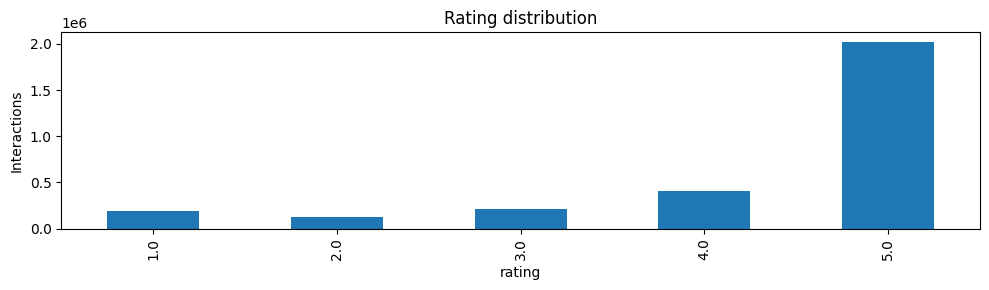

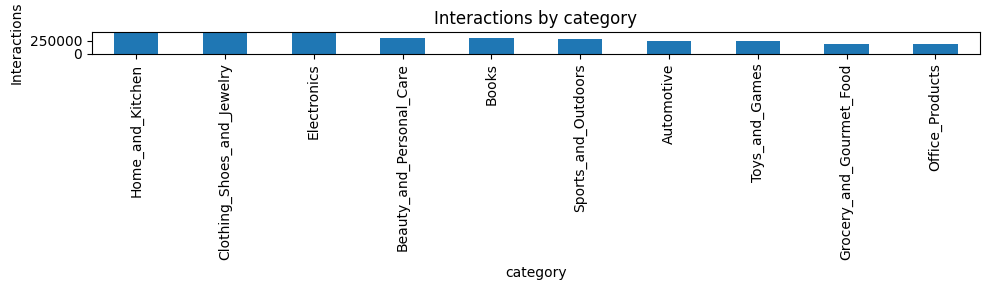

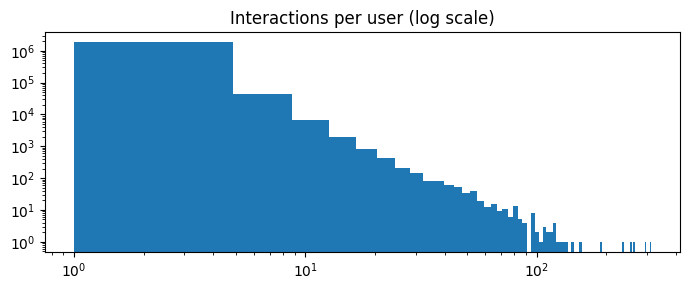

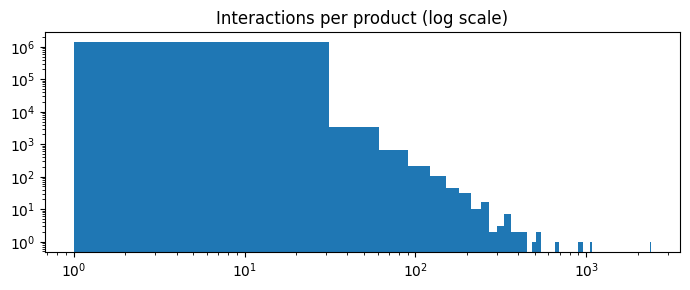

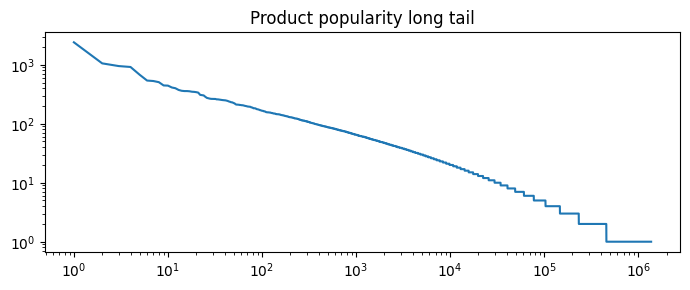

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Positive interactions (rating >= 4): 2425216


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

{
  "split_method": "deterministic per-user fallback; timestamps were unusable",
  "timestamp_valid_fraction": 0.0,
  "split_rows": {
    "train": 2109336,
    "validation": 102299,
    "test": 102425
  },
  "cf_core": {
    "interactions": 407570,
    "users": 259275,
    "products": 120770
  },
  "content_catalog_products": 120770
}


In [ ]:
# Run after colab_sections_1_2_memory_safe.py.
# This creates EDA, explicit/implicit signals, leakage-safe splits, and a
# reduced CF training core.  It does not load either large Parquet file into pandas.
import subprocess, sys, json
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'duckdb', 'pyarrow'])
from pathlib import Path
import duckdb, pandas as pd, matplotlib.pyplot as plt

ROOT = Path('/content/drive/MyDrive/ecommerce_recommender')
clean_i = ROOT/'data/cleaned/clean_interactions.parquet'
clean_p = ROOT/'data/cleaned/clean_products.parquet'
if not clean_i.exists() or not clean_p.exists():
    raise FileNotFoundError('Run the memory-safe Sections 1–2 cell first.')

con = duckdb.connect()
con.execute("PRAGMA memory_limit='5GB'")
con.execute("PRAGMA temp_directory='/content/duckdb_tmp'")
I = str(clean_i).replace("'", "''")
P = str(clean_p).replace("'", "''")

def parquet(sql, destination):
    destination = str(destination).replace("'", "''")
    con.execute(f"COPY ({sql}) TO '{destination}' (FORMAT PARQUET, COMPRESSION ZSTD)")

# SECTION 3 — EDA from aggregate queries only.
ratings = con.execute(f"SELECT rating, COUNT(*) AS n FROM read_parquet('{I}') GROUP BY 1 ORDER BY 1").df()
categories = con.execute(f"SELECT category, COUNT(*) AS n FROM read_parquet('{I}') GROUP BY 1 ORDER BY n DESC").df()
user_counts = con.execute(f"SELECT COUNT(*) AS interactions FROM read_parquet('{I}') GROUP BY user_id").df()
item_counts = con.execute(f"SELECT COUNT(*) AS interactions FROM read_parquet('{I}') GROUP BY product_id").df()
timestamp_stats = con.execute(f'''SELECT COUNT(*) AS rows, COUNT(timestamp) AS valid_timestamps,
  MIN(timestamp) AS min_timestamp, MAX(timestamp) AS max_timestamp
  FROM read_parquet('{I}')''').df().iloc[0].to_dict()
print('Timestamp quality:', timestamp_stats)
print('Users with one interaction:', int((user_counts.interactions == 1).sum()), 'of', len(user_counts))

plot_dir = ROOT/'results/plots'; plot_dir.mkdir(parents=True, exist_ok=True)
for frame, x, y, title, filename in [
    (ratings, 'rating', 'n', 'Rating distribution', 'ratings.png'),
    (categories, 'category', 'n', 'Interactions by category', 'categories.png')]:
    ax = frame.plot.bar(x=x, y=y, legend=False, figsize=(10, 3), title=title)
    ax.set_ylabel('Interactions'); plt.tight_layout(); plt.savefig(plot_dir/filename, dpi=160); plt.show()
for counts, title, filename in [(user_counts, 'Interactions per user', 'user_activity.png'),
                                (item_counts, 'Interactions per product', 'product_popularity.png')]:
    plt.figure(figsize=(7, 3)); plt.hist(counts.interactions, bins=80); plt.xscale('log'); plt.yscale('log')
    plt.title(title + ' (log scale)'); plt.tight_layout(); plt.savefig(plot_dir/filename, dpi=160); plt.show()
popularity = item_counts.interactions.sort_values(ascending=False).reset_index(drop=True)
plt.figure(figsize=(7, 3)); plt.plot(range(1, len(popularity)+1), popularity)
plt.xscale('log'); plt.yscale('log'); plt.title('Product popularity long tail'); plt.tight_layout()
plt.savefig(plot_dir/'long_tail.png', dpi=160); plt.show()

# SECTION 4 — explicit source is already clean; implicit positives use the
# observed distribution: ratings 4 and 5 represent the clear positive majority.
parquet(f"SELECT user_id, product_id, rating, timestamp, category FROM read_parquet('{I}')", ROOT/'data/model_data/explicit_interactions.parquet')
parquet(f"SELECT user_id, product_id, timestamp, category, 1.0::FLOAT AS weight FROM read_parquet('{I}') WHERE rating >= 4", ROOT/'data/model_data/implicit_positive.parquet')
positive_n = con.execute(f"SELECT COUNT(*) FROM read_parquet('{ROOT}/data/model_data/implicit_positive.parquet')").fetchone()[0]
json.dump({'positive_rule': 'rating >= 4', 'positive_rows': positive_n}, open(ROOT/'data/model_data/signal_config.json', 'w'), indent=2)
print('Positive interactions (rating >= 4):', positive_n)

# SECTION 5 — temporal split only if timestamps are genuinely valid.  Users
# with fewer than three positives remain training-only and are not evaluated.
valid_fraction = timestamp_stats['valid_timestamps'] / timestamp_stats['rows']
if valid_fraction >= .95 and timestamp_stats['min_timestamp'] != timestamp_stats['max_timestamp']:
    ranked = f'''SELECT *, row_number() OVER (PARTITION BY user_id ORDER BY timestamp, product_id) AS rn,
        count(*) OVER (PARTITION BY user_id) AS n FROM read_parquet('{ROOT}/data/model_data/implicit_positive.parquet')'''
    split_method = 'temporal per-user holdout'
else:
    ranked = f'''SELECT *, row_number() OVER (PARTITION BY user_id ORDER BY hash(user_id, product_id)) AS rn,
        count(*) OVER (PARTITION BY user_id) AS n FROM read_parquet('{ROOT}/data/model_data/implicit_positive.parquet')'''
    split_method = 'deterministic per-user fallback; timestamps were unusable'
con.execute(f'CREATE OR REPLACE TEMP VIEW ranked AS {ranked}')
parquet("SELECT user_id, product_id, timestamp, category, weight FROM ranked WHERE NOT (n >= 3 AND rn >= n - 1)", ROOT/'data/model_data/train_interactions.parquet')
parquet("SELECT user_id, product_id, timestamp, category, weight FROM ranked WHERE n >= 3 AND rn = n - 1", ROOT/'data/model_data/validation_interactions.parquet')
parquet("SELECT user_id, product_id, timestamp, category, weight FROM ranked WHERE n >= 3 AND rn = n", ROOT/'data/model_data/test_interactions.parquet')

# Exclude evaluation-only products from metrics; this prevents impossible
# cold-item targets rather than leaking them into train.
con.execute(f"CREATE OR REPLACE TEMP VIEW train_products AS SELECT DISTINCT product_id FROM read_parquet('{ROOT}/data/model_data/train_interactions.parquet')")
for name in ['validation', 'test']:
    con.execute(f"CREATE OR REPLACE TEMP VIEW tmp AS SELECT e.* FROM read_parquet('{ROOT}/data/model_data/{name}_interactions.parquet') e JOIN train_products USING(product_id)")
    final_path = ROOT/f'data/model_data/{name}_interactions.parquet'
    temporary_path = ROOT/f'data/model_data/{name}_interactions_filtered.parquet'
    parquet('SELECT * FROM tmp', temporary_path)
    temporary_path.replace(final_path)

# A 2-by-2 core is essential: one-interaction users cannot produce item
# co-occurrence, and single-occurrence items cannot support meaningful CF.
TRAIN = f"read_parquet('{ROOT}/data/model_data/train_interactions.parquet')"
con.execute(f'''CREATE OR REPLACE TEMP VIEW user2 AS SELECT user_id FROM {TRAIN} GROUP BY 1 HAVING COUNT(*) >= 2''')
con.execute(f'''CREATE OR REPLACE TEMP VIEW item2 AS SELECT product_id FROM {TRAIN} JOIN user2 USING(user_id) GROUP BY 1 HAVING COUNT(*) >= 2''')
parquet(f"SELECT t.* FROM {TRAIN} t JOIN user2 USING(user_id) JOIN item2 USING(product_id)", ROOT/'data/model_data/cf_core_train.parquet')
core_stats = con.execute(f'''SELECT COUNT(*) AS interactions, COUNT(DISTINCT user_id) AS users,
    COUNT(DISTINCT product_id) AS products FROM read_parquet('{ROOT}/data/model_data/cf_core_train.parquet')''').df().iloc[0].to_dict()

# Content is built only for products with enough collaborative evidence.  This
# avoids a 1.37M-row TF-IDF index and is still a strong practical catalog.
parquet(f'''SELECT p.* FROM read_parquet('{P}') p JOIN (
    SELECT product_id, COUNT(*) AS n FROM read_parquet('{ROOT}/data/model_data/cf_core_train.parquet')
    GROUP BY 1 ORDER BY n DESC LIMIT 250000
) c USING(product_id)''', ROOT/'data/model_data/model_catalog.parquet')
catalog_n = con.execute(f"SELECT COUNT(*) FROM read_parquet('{ROOT}/data/model_data/model_catalog.parquet')").fetchone()[0]
split_counts = {n: con.execute(f"SELECT COUNT(*) FROM read_parquet('{ROOT}/data/model_data/{n}_interactions.parquet')").fetchone()[0] for n in ['train','validation','test']}
report = {'split_method':split_method, 'timestamp_valid_fraction':valid_fraction, 'split_rows':split_counts, 'cf_core':core_stats, 'content_catalog_products':catalog_n}
json.dump(report, open(ROOT/'data/model_data/modeling_readiness.json', 'w'), indent=2, default=str)
print(json.dumps(report, indent=2, default=str))
con.close()


CF core: (407570, 5) catalog: (120770, 10)


/usr/local/lib/python3.13/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.0050923824310302734 seconds
  warnings.warn(


  0%|          | 0/120770 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

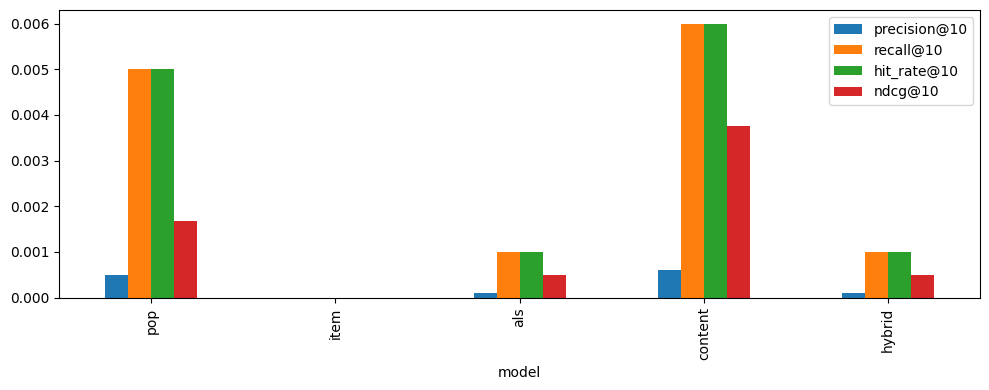

     model  precision@10  recall@10  hit_rate@10   ndcg@10
0      pop        0.0005      0.005        0.005  0.001675
1     item        0.0000      0.000        0.000  0.000000
2      als        0.0001      0.001        0.001  0.000500
3  content        0.0006      0.006        0.006  0.003762
4   hybrid        0.0001      0.001        0.001  0.000500
popular_global


,product_id,interaction_count,title,category,average_rating,popularity_score
0,B07TVHSDMQ,494,Funny Civil Engineers TShirt I'm A Crazy Civil...,Clothing_Shoes_and_Jewelry,4.7,6.204558
1,B075X8471B,288,"Fire TV Stick with Alexa Voice Remote, streami...",Electronics,4.5,5.666427
2,B01K8B8YA8,248,Echo Dot (2nd Generation) - Smart speaker with...,Electronics,4.5,5.517453


similar_item


,product_id,score,title,category,average_rating
0,B08GD2TTNS,0.223607,ZINUS 5 Inch Twin Youth Memory Foam Mattress 2...,Home_and_Kitchen,4.4
1,B07NJ13PC8,0.223607,"Torani Sugar Free Salted Caramel Syrup, 25.4 oz",Grocery_and_Gourmet_Food,4.7
2,B083JDD112,0.182574,Sougayilang Fishing Sinkers Set with Brass Sin...,Sports_and_Outdoors,4.4


personalized


...

content


,product_id,title,category,average_rating,score
0,B00MMET87S,"Rock with Wings: A Leaphorn, Chee & Manuelito ...",Books,4.3,0.456354
1,B071KYZBT5,"Cave of Bones: A Leaphorn, Chee & Manuelito No...",Books,4.4,0.426072
2,B01IMYCWSS,"Song of the Lion: A Leaphorn, Chee & Manuelito...",Books,4.4,0.417189


hybrid


,product_id,score,title,category,average_rating
0,B0C36Q7PM4,0.620900,"Amazon Basics Multipurpose Copy Printer Paper,...",Office_Products,4.8
1,B008J0Z9TA,0.309689,SanDisk Ultra 64GB MicroSDXC Class 10 UHS Memo...,Electronics,4.6
2,B07NJ13PC8,0.250000,"Torani Sugar Free Salted Caramel Syrup, 25.4 oz",Grocery_and_Gourmet_Food,4.7


{
  "dataset": {
    "split_method": "deterministic per-user fallback; timestamps were unusable",
    "timestamp_valid_fraction": 0.0,
    "split_rows": {
      "train": 2109336,
      "validation": 102299,
      "test": 102425
    },
    "cf_core": {
      "interactions": 407570,
      "users": 259275,
      "products": 120770
    },
    "content_catalog_products": 120770
  },
  "models": [
    "log-count popularity",
    "top-50 sparse item cosine",
    "48-factor implicit ALS",
    "TF-IDF nearest neighbour",
    "normalized hybrid"
  ],
  "best_model": {
    "model": "content",
    "precision@10": 0.0006,
    "recall@10": 0.006,
    "hit_rate@10": 0.006,
    "ndcg@10": 0.0037618595071429155
  },
  "cold_start": "unknown users receive popularity; products in the 120k catalog receive content/item recommendations; products outside it receive popularity only.",
  "limitations": "timestamps were unusable, therefore deterministic per-user split is used; CF is limited to the 2-by-2 intera

In [ ]:
# Run after colab_sections_3_5_memory_safe.py.  This uses only the 407k-row CF
# core and 120k-item modeling catalog; it never reads the 2.25GB raw product CSV.
from pathlib import Path
import json, random
import numpy as np, pandas as pd, scipy.sparse as sp, joblib, matplotlib.pyplot as plt
from implicit.nearest_neighbours import CosineRecommender
from implicit.als import AlternatingLeastSquares
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

ROOT=Path('/content/drive/MyDrive/ecommerce_recommender'); SEED=42; np.random.seed(SEED); random.seed(SEED)
core_path=ROOT/'data/model_data/cf_core_train.parquet'; catalog_path=ROOT/'data/model_data/model_catalog.parquet'
if not core_path.exists() or not catalog_path.exists(): raise FileNotFoundError('Run Sections 3–5 first.')
core=pd.read_parquet(core_path); catalog=pd.read_parquet(catalog_path)
for c in ['user_id','product_id']: core[c]=core[c].astype(str)
catalog.product_id=catalog.product_id.astype(str); catalog=catalog.drop_duplicates('product_id').reset_index(drop=True)
print('CF core:',core.shape,'catalog:',catalog.shape)

# SECTION 6 — popularity over the model catalog only. This is the scalable
# cold-start fallback, with log-count score and category filtering.
counts=core.groupby('product_id').size().rename('interaction_count').reset_index()
pop=counts.merge(catalog[['product_id','title','category','average_rating']],on='product_id',how='left')
pop['popularity_score']=np.log1p(pop.interaction_count); pop=pop.sort_values('popularity_score',ascending=False)
pop.to_parquet(ROOT/'models/popularity/popularity.parquet',index=False)
def recommend_popular(category=None,top_k=10):
    d=pop if category is None else pop[pop.category.astype(str).str.casefold()==str(category).casefold()]
    return d.head(top_k).reset_index(drop=True)

# SECTION 7 — item CF stores 50 sparse neighbours/item, not a dense NxN matrix.
users=pd.Index(core.user_id.unique()); items=pd.Index(core.product_id.unique()); um={v:i for i,v in enumerate(users)}; im={v:i for i,v in enumerate(items)}
ui=sp.csr_matrix((np.ones(len(core),np.float32),(core.user_id.map(um),core.product_id.map(im))),shape=(len(users),len(items)));ui.sum_duplicates();ui.data[:]=1
# implicit expects a user-by-item matrix. Passing ui.T would instead build
# user-neighbours, whose indices are invalid product indices at inference time.
item_model=CosineRecommender(K=50,num_threads=0); item_model.fit(ui.tocsr(),show_progress=True)
joblib.dump(item_model,ROOT/'models/collaborative/item_cosine_top50.joblib',compress=3);sp.save_npz(ROOT/'artifacts/mappings/cf_core_ui.npz',ui);joblib.dump({'users':users.tolist(),'items':items.tolist()},ROOT/'artifacts/mappings/cf_core_mappings.joblib',compress=3)
def details(frame): return frame.merge(catalog[['product_id','title','category','average_rating']],on='product_id',how='left')
def recommend_similar_items(product_id,top_k=10):
    if str(product_id) not in im:return pd.DataFrame()
    ids,scores=item_model.similar_items(im[str(product_id)],N=top_k+1)
    d=pd.DataFrame({'product_id':items.take(ids).astype(str),'score':scores});return details(d[d.product_id!=str(product_id)].head(top_k))

# SECTION 8 — implicit ALS over the sparse core; user history is excluded.
als=AlternatingLeastSquares(factors=48,regularization=.10,iterations=18,random_state=SEED,num_threads=0)
# Same orientation requirement: rows are users and columns are products.
als.fit(ui.tocsr(),show_progress=True);joblib.dump(als,ROOT/'models/collaborative/als_implicit_core.joblib',compress=3)
def recommend_for_user(user_id,top_k=10):
    if str(user_id) not in um:return pd.DataFrame()
    row=um[str(user_id)]; ids,scores=als.recommend(row,ui[row],N=top_k,filter_already_liked_items=True)
    return details(pd.DataFrame({'product_id':items.take(ids).astype(str),'score':scores}))

# SECTION 9 — local, zero-API-cost TF-IDF content NN over the capped catalog.
text=catalog.product_text.fillna('').astype(str) if 'product_text' in catalog else (catalog.title.fillna('')+' '+catalog.category.fillna(''))
vectorizer=TfidfVectorizer(stop_words='english',max_features=100000,min_df=2,max_df=.98,ngram_range=(1,2),dtype=np.float32,sublinear_tf=True)
X=vectorizer.fit_transform(text); content_nn=NearestNeighbors(metric='cosine',algorithm='brute',n_jobs=-1).fit(X)
joblib.dump(vectorizer,ROOT/'models/content/tfidf_vectorizer.joblib',compress=3);joblib.dump(content_nn,ROOT/'models/content/content_nn.joblib',compress=3);joblib.dump(catalog.product_id.tolist(),ROOT/'artifacts/mappings/content_product_ids.joblib')
content_index={v:i for i,v in enumerate(catalog.product_id)}
def recommend_content(product_id,top_k=10):
    if str(product_id) not in content_index:return pd.DataFrame()
    d,idx=content_nn.kneighbors(X[content_index[str(product_id)]],n_neighbors=min(top_k+1,len(catalog)))
    out=catalog.iloc[idx[0]][['product_id','title','category','average_rating']].copy();out['score']=1-d[0]
    return out[out.product_id!=str(product_id)].head(top_k).reset_index(drop=True)

# SECTION 10 — hybrid candidate fusion. Scores are min-max normalized inside
# each candidate source, so their native score scales are never mixed directly.
CFG={'als':0.60,'similar_or_content':0.25,'popularity':0.15,'candidate_k':100};json.dump(CFG,open(ROOT/'models/hybrid/config.json','w'),indent=2)
def normal(d):
    d=d.copy(); x=d.score.astype(float);d.score=(x-x.min())/(x.max()-x.min()+1e-12);return d
def recommend_hybrid(user_id=None,product_id=None,category=None,top_k=10):
    parts=[]
    if user_id is not None:
        d=recommend_for_user(user_id,CFG['candidate_k'])
        if not d.empty:parts.append((normal(d[['product_id','score']]),CFG['als']))
    if product_id is not None:
        d=recommend_similar_items(product_id,CFG['candidate_k'])
        if d.empty:d=recommend_content(product_id,CFG['candidate_k'])
        if not d.empty:parts.append((normal(d[['product_id','score']]),CFG['similar_or_content']))
    d=normal(recommend_popular(category,CFG['candidate_k']).rename(columns={'popularity_score':'score'})[['product_id','score']]);parts.append((d,CFG['popularity']))
    final=pd.concat([z.assign(score=z.score*w) for z,w in parts]).groupby('product_id',as_index=False).score.sum().nlargest(top_k,'score')
    return details(final)

# SECTION 11 — leakage-safe sampled evaluation. Test targets, users and items
# must all occur in the CF-core training universe; this is documented in output.
test=pd.read_parquet(ROOT/'data/model_data/test_interactions.parquet');test.user_id=test.user_id.astype(str);test.product_id=test.product_id.astype(str)
test=test[test.user_id.isin(um)&test.product_id.isin(im)]; truth=test.groupby('user_id').product_id.agg(set).to_dict()
history=core.groupby('user_id').product_id.agg(set).to_dict(); last=core.groupby('user_id').product_id.last().to_dict()
sample=pd.Series(list(truth)).sample(min(1000,len(truth)),random_state=SEED).tolist()
from math import log2
def evaluate(name,k=10):
    values=[]
    for u in sample:
        if name=='pop': d=recommend_popular(top_k=k)
        elif name=='item': d=recommend_similar_items(last[u],k)
        elif name=='als': d=recommend_for_user(u,k)
        elif name=='content': d=recommend_content(last[u],k)
        else:d=recommend_hybrid(u,last[u],top_k=k)
        rec=[str(x) for x in d.product_id if str(x) not in history[u]][:k]; hits=[j for j,x in enumerate(rec) if x in truth[u]]
        ideal=sum(1/log2(j+2) for j in range(min(k,len(truth[u])))); values.append([len(hits)/k,len(hits)/len(truth[u]),float(bool(hits)),sum(1/log2(j+2) for j in hits)/ideal])
    return np.mean(values,axis=0)
comparison=pd.DataFrame([dict(zip(['model','precision@10','recall@10','hit_rate@10','ndcg@10'],[name,*evaluate(name)])) for name in ['pop','item','als','content','hybrid']])
comparison.to_csv(ROOT/'data/evaluation/model_comparison.csv',index=False);comparison.set_index('model').plot.bar(figsize=(10,4));plt.tight_layout();plt.savefig(ROOT/'results/plots/model_comparison.png',dpi=160);plt.show();print(comparison)

# SECTION 12 — report-ready examples.
examples={'popular_global':recommend_popular(top_k=10),'similar_item':recommend_similar_items(items[0]),'personalized':recommend_for_user(users[0]),'content':recommend_content(catalog.product_id.iloc[0]),'hybrid':recommend_hybrid(users[0],items[0])}
for name,frame in examples.items():frame.to_csv(ROOT/f'results/recommendations/{name}.csv',index=False);print(name);display(frame.head(3))

# SECTION 13/14 — inference-only artifact manifest and API functions are the
# six functions above. Streamlit loads these files and never calls fit/train.
catalog.to_parquet(ROOT/'artifacts/model_catalog.parquet',index=False)
manifest={'catalog':'artifacts/model_catalog.parquet','popularity':'models/popularity/popularity.parquet','item_cf':'models/collaborative/item_cosine_top50.joblib','als':'models/collaborative/als_implicit_core.joblib','ui':'artifacts/mappings/cf_core_ui.npz','mappings':'artifacts/mappings/cf_core_mappings.joblib','tfidf':'models/content/tfidf_vectorizer.joblib','content_nn':'models/content/content_nn.joblib','content_ids':'artifacts/mappings/content_product_ids.joblib','hybrid_config':'models/hybrid/config.json'}
json.dump(manifest,open(ROOT/'artifacts/inference_manifest.json','w'),indent=2)

# SECTION 15 — final summary.
readiness=json.load(open(ROOT/'data/model_data/modeling_readiness.json'))
final={'dataset':readiness,'models':['log-count popularity','top-50 sparse item cosine','48-factor implicit ALS','TF-IDF nearest neighbour','normalized hybrid'],'best_model':comparison.sort_values('ndcg@10',ascending=False).iloc[0].to_dict(),'cold_start':'unknown users receive popularity; products in the 120k catalog receive content/item recommendations; products outside it receive popularity only.','limitations':'timestamps were unusable, therefore deterministic per-user split is used; CF is limited to the 2-by-2 interaction core.'}
json.dump(final,open(ROOT/'results/final_project_summary.json','w'),indent=2,default=str);print(json.dumps(final,indent=2,default=str))


In [1]:
!pip install streamlit implicit pyarrow scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 123.6 MB/s eta 0:00:00


In [8]:
!streamlit run /content/drive/MyDrive/ecommerce_recommender/streamlit_app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [2]:
!pkill -f "streamlit run /content/drive/MyDrive/ecommerce_recommender/streamlit_app.py" || true

!streamlit run /content/drive/MyDrive/ecommerce_recommender/streamlit_app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  --server.headless true \
  > /content/streamlit.log 2>&1 &

^C


In [3]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501, height=900)

<IPython.core.display.Javascript object>

In [4]:
!tail -50 /content/streamlit.log



2026-09-03 08:35:58.063 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.149.220:8501



In [5]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Open this URL:")
print(url)

Open this URL:
https://8501-gpu-t4-s-kkb-usw4a2-c32ipwn1eec0-a.us-west4-2.prod.colab.dev
